In [ ]:
# Bootstrap repo into Colab
# autoreload dropped: Python 3.12 removed `imp` which this Colab's IPython
# autoreload extension still depends on. We restart-kernel + re-import when
# a module we already loaded gets updated. New modules import cleanly.
import os, subprocess, sys

REPO_DIR = "/content/fitnova"
BRANCH = "fresh-start"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print("repo at      :", REPO_DIR)
print("sys.path[0]  :", sys.path[0])
print("python       :", sys.version.split()[0])
print("HEAD:")
subprocess.run(["git", "-C", REPO_DIR, "log", "--oneline", "-5"])

repo at      : /content/fitnova
sys.path[0]  : /content/fitnova
python       : 3.12.13
HEAD:


CompletedProcess(args=['git', '-C', '/content/fitnova', 'log', '--oneline', '-5'], returncode=0)

In [ ]:
# Surface the git HEAD
!cd /content/fitnova && git log --oneline -5

9f6d6e8 (HEAD -> fresh-start, origin/fresh-start) fix(02): flat extract + migrate nested mp4s in stage_squat_videos (Task 7)
fab28ed fix(02): stage_squat_videos byte-level + per-member resume (Task 7)
55d3174 chore(02): add tqdm progress to stage_squat_videos copy + extract (Task 7)
f65adee feat(02): implement harness/colab.py slice 1 + Step 4/4b notebook cells (Task 7)
bc863ad feat(02): implement datasets/squat.py + Step 3 notebook cell (Task 6)


In [ ]:
# Cell B — environment setup from 02_squat_pipeline_harness.py
from backend.training.aqa.harness import _envinit  # sets CUBLAS_WORKSPACE_CONFIG before torch

import os
import sys
import torch
import torchvision

print("python       :", sys.version.split()[0])
print("torch        :", torch.__version__)
print("torchvision  :", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device  :", torch.cuda.get_device_name(0))

print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

from google.colab import drive
drive.mount('/content/drive')

MYDRIVE = '/content/drive/MyDrive'
ROOT = os.path.join(MYDRIVE, 'Fitness-AQA_dataset_release')
print("\nROOT  :", ROOT)
print("exists:", os.path.exists(ROOT))

python       : 3.12.13
torch        : 2.10.0+cu128
torchvision  : 0.25.0+cu128
CUDA available: True
CUDA device  : Tesla T4
CUBLAS_WORKSPACE_CONFIG: :4096:8
Mounted at /content/drive

ROOT  : /content/drive/MyDrive/Fitness-AQA_dataset_release
exists: True


In [ ]:
# Cell C — decoder availability check (decoder prerequisite)
import torchvision, torchvision.io
print("torchvision        :", torchvision.__version__)
print("read_video exists  :", hasattr(torchvision.io, "read_video"))
print("read_video_timestamps:", hasattr(torchvision.io, "read_video_timestamps"))
try:
    import torchcodec
    print("torchcodec         :", torchcodec.__version__)
    print("VideoDecoder exists:", hasattr(torchcodec.decoders, "VideoDecoder"))
except ModuleNotFoundError:
    print("torchcodec         : NOT INSTALLED (would need pip install)")
import warnings
warnings.simplefilter("error", DeprecationWarning)
try:
    # Just import sanity, no decode yet
    _ = torchvision.io.read_video
    print("read_video import-clean : True")
except DeprecationWarning as e:
    print("read_video import-clean : False (DeprecationWarning):", e)
except Exception as e:
    print("read_video access error :", type(e).__name__, e)

torchvision        : 0.25.0+cu128
read_video exists  : True
read_video_timestamps: True


In [ ]:
# Cell D — pull the new commit
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
Already up to date.
8a250c5 (HEAD -> fresh-start, origin/fresh-start) feat(02): implement datasets/splits.py + Step 1 notebook cell (Task 4)
eeca4b9 feat(02): scaffold AQA pipeline modules + figures + notebook stub (Task 3)
9aa3d6b docs(02): document Code_Release gap analysis (Task 2)


In [ ]:
# Cell E — official splits + labels
from backend.training.aqa.datasets.splits import index, expected_counts, ClipRecord

DRIVE_ROOT = "/content/drive/MyDrive"
VIDEOS_ROOT = "/content/squat_videos"   # interpolated into record.video_path; not opened here

print("expected counts:", expected_counts())
print()

all_ids: dict[str, set[str]] = {}
for split_name in ("train", "val", "test"):
    recs = index(split_name, drive_root=DRIVE_ROOT, videos_root=VIDEOS_ROOT)
    kie_pos = sum(r.label_kie for r in recs)
    kfe_pos = sum(r.label_kfe for r in recs)
    print(f"{split_name:5s}: {len(recs):4d} records   KIE+ {kie_pos:3d}   KFE+ {kfe_pos:3d}")
    all_ids[split_name] = {r.clip_id for r in recs}

print()
print("=== disjointness check (split invariant) ===")
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    overlap = all_ids[a] & all_ids[b]
    print(f"{a} ∩ {b}: {len(overlap)} overlapping ids (must be 0)")

print()
print("=== first train record (spot check) ===")
first = index("train", drive_root=DRIVE_ROOT, videos_root=VIDEOS_ROOT)[0]
print(first)

expected counts: {'train': 1136, 'val': 243, 'test': 244}

train: 1136 records   KIE+ 160   KFE+ 782
val  :  243 records   KIE+  36   KFE+ 158
test :  244 records   KIE+  36   KFE+ 169

=== disjointness check (Phase 1 invariant) ===
train ∩ val: 0 overlapping ids (must be 0)
train ∩ test: 0 overlapping ids (must be 0)
val ∩ test: 0 overlapping ids (must be 0)

=== first train record (spot check) ===
ClipRecord(clip_id='46777_1', video_path='/content/squat_videos/46777_1.mp4', label_kie=0, label_kfe=1)


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 6.45 KiB | 2.15 MiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   8a250c5..d89932f  fresh-start -> origin/fresh-start
Updating 8a250c5..d89932f
Fast-forward
 backend/training/aqa/datasets/transforms.py        | 233 ++++++++++++++++++++-
 .../aqa/notebooks/02_squat_pipeline_harness.py     |  27 ++-
 2 files changed, 253 insertions(+), 7 deletions(-)
d89932f (HEAD -> fresh-start, origin/fresh-start) feat(02): implement datasets/transforms.py + Step 2 notebook cell (Task 5)
8a250c5 feat(02): implement datasets/splits.py + Step 1 notebook cell (Task 4)
eeca4b9 feat(02): scaffold AQA pipeline modules + figures + notebook stub (Task 3)


In [ ]:
# Cell G — transforms synthetic smoke
import sys, subprocess
result = subprocess.run(
    [sys.executable, "/content/fitnova/backend/training/aqa/datasets/transforms.py"],
    capture_output=True, text=True,
)
print("--- stdout ---")
print(result.stdout)
if result.returncode != 0:
    print("--- stderr ---")
    print(result.stderr)
    raise RuntimeError(f"transforms.py smoke failed (exit {result.returncode})")

--- stdout ---
transforms.py smoke: ok
  uniform_sample_indices(60, 32, jitter=0)[:8] = [0, 2, 4, 6, 8, 10, 11, 13]
  uniform_sample_indices(60, 32, jitter=2)[:8] = [0, 2, 3, 8, 7, 8, 9, 15]
  spatial_train  shape = (3, 60, 112, 112)  mean=+0.439
  spatial_val    shape = (3, 60, 112, 112)    mean=+0.439



In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 5.60 KiB | 1.87 MiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   d89932f..bc863ad  fresh-start -> origin/fresh-start
Updating d89932f..bc863ad
Fast-forward
 backend/training/aqa/datasets/squat.py             | 193 ++++++++++++++++++++-
 .../aqa/notebooks/02_squat_pipeline_harness.py     |  65 ++++++-
 2 files changed, 252 insertions(+), 6 deletions(-)
bc863ad (HEAD -> fresh-start, origin/fresh-start) feat(02): implement datasets/squat.py + Step 3 notebook cell (Task 6)
d89932f feat(02): implement datasets/transforms.py + Step 2 notebook cell (Task 5)
8a250c5 feat(02): implement datasets/splits.py + Step 1 notebook cell (Task 4)


In [ ]:
# Cell I — dataset + loaders
import os
import torch
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset, build_loaders

DRIVE_ROOT = "/content/drive/MyDrive"
VIDEOS_ROOT = "/content/squat_videos"

loaders = build_loaders(
    drive_root=DRIVE_ROOT,
    videos_root=VIDEOS_ROOT,
    batch_size=2,
)

print("=== per-split lengths + pos_weight ===")
for name in ("train", "val", "test"):
    ds = loaders[name].dataset
    print(f"{name:5s}: len={len(ds):4d}  pos_weight={ds.pos_weight.tolist()}")

train_pw = loaders["train"].dataset.pos_weight
val_pw = loaders["val"].dataset.pos_weight
test_pw = loaders["test"].dataset.pos_weight
assert torch.equal(train_pw, val_pw), "val pos_weight ≠ train"
assert torch.equal(train_pw, test_pw), "test pos_weight ≠ train"
print("\npos_weight identity across loaders: OK")

lengths_ok = (
    len(loaders["train"].dataset) == 1136
    and len(loaders["val"].dataset) == 243
    and len(loaders["test"].dataset) == 244
)
print(f"len reconciles to expected (1136/243/244): {lengths_ok}")

w_kie, w_kfe = train_pw.tolist()
print(f"\npos_weight check:")
print(f"  KIE w = {w_kie:.4f}  (expected 6.10: 160 KIE+ / 1136)")
print(f"  KFE w = {w_kfe:.4f}  (expected 0.4527: 782 KFE+ / 1136)")

if os.path.isdir(VIDEOS_ROOT) and any(f.endswith(".mp4") for f in os.listdir(VIDEOS_ROOT)):
    print("\n=== batch shape (videos staged — full check) ===")
    batch = next(iter(loaders["train"]))
    clip, labels = batch
    print(f"clip.shape   = {tuple(clip.shape)}    dtype = {clip.dtype}")
    print(f"labels.shape = {tuple(labels.shape)}  dtype = {labels.dtype}")
    print(f"labels[0]    = {labels[0].tolist()}")
    assert tuple(clip.shape) == (2, 3, 32, 112, 112)
    assert tuple(labels.shape) == (2, 2)
    print("batch shape contract: OK")
else:
    print("\n/content/squat_videos/ not staged yet — batch-shape verification deferred until videos are staged.")

=== per-split lengths + pos_weight ===
train: len=1136  pos_weight=[6.099999904632568, 0.4526854157447815]
val  : len= 243  pos_weight=[6.099999904632568, 0.4526854157447815]
test : len= 244  pos_weight=[6.099999904632568, 0.4526854157447815]

pos_weight identity across loaders: OK
len reconciles to Phase 1 (1136/243/244): True

pos_weight check:
  KIE w = 6.1000  (expected 6.10 from Phase 1: 160 KIE+ / 1136)
  KFE w = 0.4527  (expected 0.4527 from Phase 1: 782 KFE+ / 1136)

/content/squat_videos/ not staged yet — batch-shape verification deferred to Task 7.


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 6.08 KiB | 2.03 MiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   bc863ad..f65adee  fresh-start -> origin/fresh-start
Updating bc863ad..f65adee
Fast-forward
 backend/training/aqa/harness/colab.py              | 193 ++++++++++++++++++++-
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 115 +++++++++++-
 2 files changed, 301 insertions(+), 7 deletions(-)
f65adee (HEAD -> fresh-start, origin/fresh-start) feat(02): implement harness/colab.py slice 1 + Step 4/4b notebook cells (Task 7)
bc863ad feat(02): implement datasets/squat.py + Step 3 notebook cell (Task 6)
d89932f feat(02): implement datasets/transforms.py + Step 2 notebook cell (Task 5)


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 3.55 KiB | 1.78 MiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   55d3174..fab28ed  fresh-start -> origin/fresh-start
Updating 55d3174..fab28ed
Fast-forward
 backend/training/aqa/harness/colab.py | 169 +++++++++++++++++++++++++---------
 1 file changed, 124 insertions(+), 45 deletions(-)
fab28ed (HEAD -> fresh-start, origin/fresh-start) fix(02): stage_squat_videos byte-level + per-member resume (Task 7)
55d3174 chore(02): add tqdm progress to stage_squat_videos copy + extract (Task 7)
f65adee feat(02): implement harness/colab.py slice 1 + Step 4/4b notebook cells (Task 7)


In [ ]:
from backend.training.aqa.harness.colab import mount_drive, stage_squat_videos

mydrive = mount_drive()
print("MyDrive:", mydrive)

local_root = stage_squat_videos(mydrive)
print("local_root:", local_root)

import os
mp4_count = sum(1 for f in os.listdir(local_root) if f.endswith(".mp4"))
print(f"\nmp4 count in {local_root}: {mp4_count}")
assert mp4_count == 1739, f"expected 1739 mp4s, got {mp4_count}"

MyDrive: /content/drive/MyDrive
local_root: /content/squat_videos

mp4 count in /content/squat_videos: 0


AssertionError: expected 1739 mp4s, got 0

In [ ]:
# Cell M — diagnose the zip layout
import os
from pathlib import Path

root = Path("/content/squat_videos")

print("=== top-level entries in /content/squat_videos/ ===")
for entry in sorted(root.iterdir()):
    kind = 'D' if entry.is_dir() else 'F'
    print(f"  [{kind}]  {entry.name}")

# Sample one .mp4 path to check depth + parent dir
sample = next(root.rglob("*.mp4"), None)
print(f"\nsample .mp4 (full path): {sample}")

# Count: recursive vs top-level
n_recursive = sum(1 for _ in root.rglob("*.mp4"))
n_top = sum(1 for f in root.iterdir() if f.is_file() and f.suffix == ".mp4")
print(f"\ntotal .mp4 recursive : {n_recursive}")
print(f"total .mp4 top-level : {n_top}")

# If there's exactly one subdir, show how many .mp4 live in it
subdirs = [d for d in root.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    sd = subdirs[0]
    n_in_sd = sum(1 for f in sd.iterdir() if f.is_file() and f.suffix == ".mp4")
    print(f"single subdir {sd.name}/: {n_in_sd} .mp4 directly inside")
elif len(subdirs) > 1:
    print(f"multiple subdirs: {[d.name for d in subdirs]}")

=== top-level entries in /content/squat_videos/ ===
  [D]  videos

sample .mp4 (full path): /content/squat_videos/videos/46549_1.mp4

total .mp4 recursive : 1739
total .mp4 top-level : 0
single subdir videos/: 1739 .mp4 directly inside


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 4.32 KiB | 1.44 MiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   fab28ed..9f6d6e8  fresh-start -> origin/fresh-start
Updating fab28ed..9f6d6e8
Fast-forward
 backend/training/aqa/harness/colab.py | 208 +++++++++++++++++++++++++++-------
 1 file changed, 166 insertions(+), 42 deletions(-)
9f6d6e8 (HEAD -> fresh-start, origin/fresh-start) fix(02): flat extract + migrate nested mp4s in stage_squat_videos (Task 7)
fab28ed fix(02): stage_squat_videos byte-level + per-member resume (Task 7)
55d3174 chore(02): add tqdm progress to stage_squat_videos copy + extract (Task 7)


In [ ]:
from backend.training.aqa.harness.colab import mount_drive, stage_squat_videos

mydrive = mount_drive()
print("MyDrive:", mydrive)

local_root = stage_squat_videos(mydrive)
print("local_root:", local_root)

import os
mp4_count = sum(1 for f in os.listdir(local_root) if f.endswith(".mp4"))
print(f"\nmp4 count in {local_root}: {mp4_count}")
assert mp4_count == 1739, f"expected 1739 mp4s, got {mp4_count}"

MyDrive: /content/drive/MyDrive
local_root: /content/squat_videos

mp4 count in /content/squat_videos: 0


AssertionError: expected 1739 mp4s, got 0

In [ ]:
# Cell P — force-reload the harness package, then re-stage.
# Required because we don't have %autoreload available; sys.modules holds the
# OLD colab.py from Cell K's import, even after git pull updated the file.
import sys

for k in list(sys.modules):
    if k.startswith("backend.training.aqa.harness") or k.startswith("backend.training.aqa.datasets"):
        del sys.modules[k]

# Now a fresh import picks up the latest disk version.
from backend.training.aqa.harness.colab import mount_drive, stage_squat_videos
print("stage_squat_videos sourced from:", stage_squat_videos.__code__.co_filename)
print("stage_squat_videos source line :", stage_squat_videos.__code__.co_firstlineno)

mydrive = mount_drive()
print("\nMyDrive:", mydrive)

local_root = stage_squat_videos(mydrive)
print("local_root:", local_root)

import os
mp4_count = sum(1 for f in os.listdir(local_root) if f.endswith(".mp4"))
print(f"\nmp4 count in {local_root}: {mp4_count}  (flat, top-level)")
assert mp4_count == 1739, f"expected 1739 mp4s, got {mp4_count}"

stage_squat_videos sourced from: /content/fitnova/backend/training/aqa/harness/colab.py
stage_squat_videos source line : 293

MyDrive: /content/drive/MyDrive


local_root: /content/squat_videos

mp4 count in /content/squat_videos: 1739  (flat, top-level)


In [ ]:
!pip install -q -U "ipython>=8.13"
import IPython; print("installed IPython:", IPython.__version__)
print("\n>>> Now restart the kernel: Runtime menu -> Restart session (Ctrl+M .)\n>>> /content/ files survive; Drive mount may need re-auth.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
installed IPython: 7.34.0

>>> Now restart the kernel: Runtime menu -> Restart session (Ctrl+M .)
>>> /content/ files survive; Drive mount may need re-auth.


In [ ]:
# Cell Q-rollback — revert the bad upgrade so google.colab stays happy.
# No kernel restart; current session is still on 7.34.0 in memory anyway.
!pip install -q "ipython==7.34.0" "decorator<5.0"
import IPython
print("running IPython (in memory) :", IPython.__version__)
print("on-disk IPython now pinned to 7.34.0 — google.colab pin satisfied")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.2 MB/s eta 0:00:00
running IPython (in memory) : 7.34.0
on-disk IPython now pinned to 7.34.0 — google.colab pin satisfied


In [ ]:
# Cell Q-autoreload — fake-import 'imp' so IPython 7.34.0's autoreload loads.
# imp was removed in Python 3.12; the autoreload extension on this Colab still does
# `from imp import reload`. We supply a tiny module-shaped object exposing
# importlib.reload under the name `imp.reload` — exactly what autoreload uses.
import sys, types, importlib

if "imp" not in sys.modules:
    _imp_shim = types.ModuleType("imp")
    _imp_shim.reload = importlib.reload  # type: ignore[attr-defined]
    sys.modules["imp"] = _imp_shim
    print("imp shim installed")
else:
    print("imp shim already present")

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
print("autoreload enabled")

imp shim installed
%autoreload 2 — module edits reload on next cell automatically


In [ ]:
# Cell Q-verify — sanity check: edit a known module on disk via git pull,
# then re-import and confirm the live function reflects the new file.
import subprocess
subprocess.run(["git", "-C", "/content/fitnova", "pull", "--ff-only", "origin", "fresh-start"], check=True)

# Force fresh import of the harness package for this verification step.
import sys
for k in list(sys.modules):
    if k.startswith("backend.training.aqa.harness"):
        del sys.modules[k]

from backend.training.aqa.harness.colab import stage_squat_videos
print("stage_squat_videos sourced from:", stage_squat_videos.__code__.co_filename)
print("source line :", stage_squat_videos.__code__.co_firstlineno)
print("\nFrom now on, after each `git pull`, autoreload picks up edits without manual purge.")

stage_squat_videos sourced from: /content/fitnova/backend/training/aqa/harness/colab.py
source line : 293

From now on, after each `git pull`, autoreload picks up edits without manual purge.


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 3.49 KiB | 396.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   9f6d6e8..65ab9c0  fresh-start -> origin/fresh-start
Updating 9f6d6e8..65ab9c0
Fast-forward
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 97 +++++++++++++++++++++-
 1 file changed, 93 insertions(+), 4 deletions(-)
65ab9c0 (HEAD -> fresh-start, origin/fresh-start) feat(02): Step 5 decoded-batch visualization cell (Task 8)
9f6d6e8 fix(02): flat extract + migrate nested mp4s in stage_squat_videos (Task 7)
fab28ed fix(02): stage_squat_videos byte-level + per-member resume (Task 7)


In [ ]:
# Cell U — install PyAV (torchvision.io backend) for the current session.
!pip install -q av
import av
print("PyAV installed:", av.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 50.3 MB/s eta 0:00:00
PyAV installed: 17.0.1


In [ ]:
# Cell V — clear torchvision's stale av-import cache from THIS session.
# the bootstrap step now installs av before torch/torchvision so future sessions don't hit this.
import sys

for mod in list(sys.modules):
    if mod.startswith("torchvision") or mod.startswith("backend.training.aqa"):
        del sys.modules[mod]

import torchvision
import torchvision.io
print("reloaded torchvision; torchvision.io.read_video_timestamps:", torchvision.io.read_video_timestamps)

# Sanity probe on a real Squat mp4 — proves the av backend is wired.
ts, fps = torchvision.io.read_video_timestamps(
    "/content/squat_videos/46777_1.mp4", pts_unit="sec",
)
print(f"probe ok — fps={fps}, num_frames={len(ts)}  (clip 46777_1)")

RuntimeError: This is not allowed since there's already a kernel registered from python overriding roi_align's behavior for Meta dispatch key and torchvision namespace.

In [ ]:
# decoded-batch visualization
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from backend.training.aqa.datasets.transforms import KINETICS_MEAN, KINETICS_STD
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset

train_ds = SquatKIEKFEDataset(
    split="train",
    drive_root="/content/drive/MyDrive",
    videos_root="/content/squat_videos",
    train_aug=True,
    seed=42,
)

items = [train_ds[i] for i in (0, 1)]
batch_clips = torch.stack([c for c, _ in items])
batch_labels = torch.stack([l for _, l in items])
clip_ids = [train_ds.records[i].clip_id for i in (0, 1)]

mean_t = torch.tensor(KINETICS_MEAN, dtype=torch.float32).view(3, 1, 1, 1)
std_t = torch.tensor(KINETICS_STD, dtype=torch.float32).view(3, 1, 1, 1)
display = (batch_clips * std_t.unsqueeze(0) + mean_t.unsqueeze(0)).clamp(0, 1)

frame_idx = np.linspace(0, 31, 8).round().astype(int)

fig, axes = plt.subplots(2, 8, figsize=(16, 5), dpi=120)
for row in range(2):
    label_kie = int(batch_labels[row, 0].item())
    label_kfe = int(batch_labels[row, 1].item())
    for col, fi in enumerate(frame_idx):
        ax = axes[row, col]
        frame = display[row, :, fi].permute(1, 2, 0).numpy()
        ax.imshow(frame)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"t={fi}", fontsize=8)
    axes[row, 0].text(
        -0.18, 0.5,
        f"{clip_ids[row]}\nKIE={label_kie}\nKFE={label_kfe}",
        fontsize=9, ha="right", va="center",
        transform=axes[row, 0].transAxes,
    )
fig.suptitle("Decoded-and-augmented Squat batch", fontsize=11, y=1.02)
plt.tight_layout()

FIG_PATH = Path("docs/figures/decoded_batch.png")
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_PATH, dpi=120, bbox_inches="tight")
print(f"saved : {FIG_PATH}")
print(f"size  : {FIG_PATH.stat().st_size / 1024:.1f} KB")
print(f"shape : batch={tuple(batch_clips.shape)} labels={tuple(batch_labels.shape)}")
print(f"clips : {clip_ids}")
print(f"labels: row0={batch_labels[0].tolist()} row1={batch_labels[1].tolist()}")
plt.show()

ImportError: PyAV is not installed, and is necessary for the video operations in torchvision.
See https://github.com/mikeboers/PyAV#installation for instructions on how to
install PyAV on your system.


In [ ]:
# Cell W — post-restart bootstrap: repo on sys.path + imp shim + autoreload
import os, sys, subprocess, types, importlib

REPO_DIR = "/content/fitnova"
BRANCH = "fresh-start"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# imp shim — required for IPython 7.34.0's autoreload to load on Python 3.12.
if "imp" not in sys.modules:
    _imp_shim = types.ModuleType("imp")
    _imp_shim.reload = importlib.reload  # type: ignore[attr-defined]
    sys.modules["imp"] = _imp_shim

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")

print("=== bootstrap complete ===")
print("sys.path[0]:", sys.path[0])
print("\nHEAD:")
subprocess.run(["git", "-C", REPO_DIR, "log", "--oneline", "-3"])

=== bootstrap complete ===
sys.path[0]: /content/fitnova

HEAD:


CompletedProcess(args=['git', '-C', '/content/fitnova', 'log', '--oneline', '-3'], returncode=0)

In [ ]:
!cd /content/fitnova && git log --oneline -3
import sys
print("\nimp shim present :", "imp" in sys.modules)
print("autoreload loaded:", "autoreload" in get_ipython().extension_manager.loaded)

69c3870 (HEAD -> fresh-start, origin/fresh-start) chore(02): auto-install PyAV in notebook Step 0 (Task 8 prereq)
65ab9c0 feat(02): Step 5 decoded-batch visualization cell (Task 8)
9f6d6e8 fix(02): flat extract + migrate nested mp4s in stage_squat_videos (Task 7)

imp shim present : True
autoreload loaded: True


In [ ]:
from backend.training.aqa.harness import _envinit  # sets CUBLAS_WORKSPACE_CONFIG before torch

import os, sys, subprocess

# Idempotent PyAV install — torchvision.io needs it as the FFmpeg backend.
try:
    import av
    _pyav_status = "already installed"
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "av"], check=True)
    import av
    _pyav_status = "installed now"
print(f"PyAV {av.__version__} ({_pyav_status})")

import torch
import torchvision

print("python   :", sys.version.split()[0])
print("torch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device :", torch.cuda.get_device_name(0))
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# Quick proof PyAV is wired into torchvision.io this time:
ts, fps = torchvision.io.read_video_timestamps(
    "/content/squat_videos/46777_1.mp4", pts_unit="sec",
)
print(f"\ntorchvision.io probe: fps={fps}, num_frames={len(ts)}  (PyAV backend working)")

from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

PyAV 17.0.1 (installed by Step 0)
python   : 3.12.13
torch    : 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA available: True
CUDA device : Tesla T4
CUBLAS_WORKSPACE_CONFIG: :4096:8

torchvision.io probe: fps=None, num_frames=0  (PyAV backend working)


/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/video.py:461: RuntimeWarning: Failed to open container for /content/squat_videos/46777_1.mp4; Caught error: [Errno 2] No such file or directory: '/content/squat_videos/46777_1.mp4'
  warnings.warn(msg, RuntimeWarning)


Mounted at /content/drive
Drive mounted


In [ ]:
# Re-stage from Drive (kernel restart wiped /content/squat_videos/).
# stage_squat_videos handles cache miss -> full copy + flat-extract automatically.
from backend.training.aqa.harness.colab import stage_squat_videos

local_root = stage_squat_videos("/content/drive/MyDrive")
print("local_root:", local_root)

import os
mp4_count = sum(1 for f in os.listdir(local_root) if f.endswith(".mp4"))
print(f"flat mp4 count: {mp4_count}")
assert mp4_count == 1739, f"expected 1739 mp4s, got {mp4_count}"

local_root: /content/squat_videos
flat mp4 count: 1739


/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


saved : /content/fitnova/.planning/phases/02-squat-data-pipeline-colab-harness/figures/decoded_batch.png
size  : 1013.1 KB
shape : batch=(2, 3, 32, 112, 112) labels=(2, 2)
clips : ['46777_1', '49897_1']
labels: row0=[0.0, 1.0] row1=[1.0, 1.0]


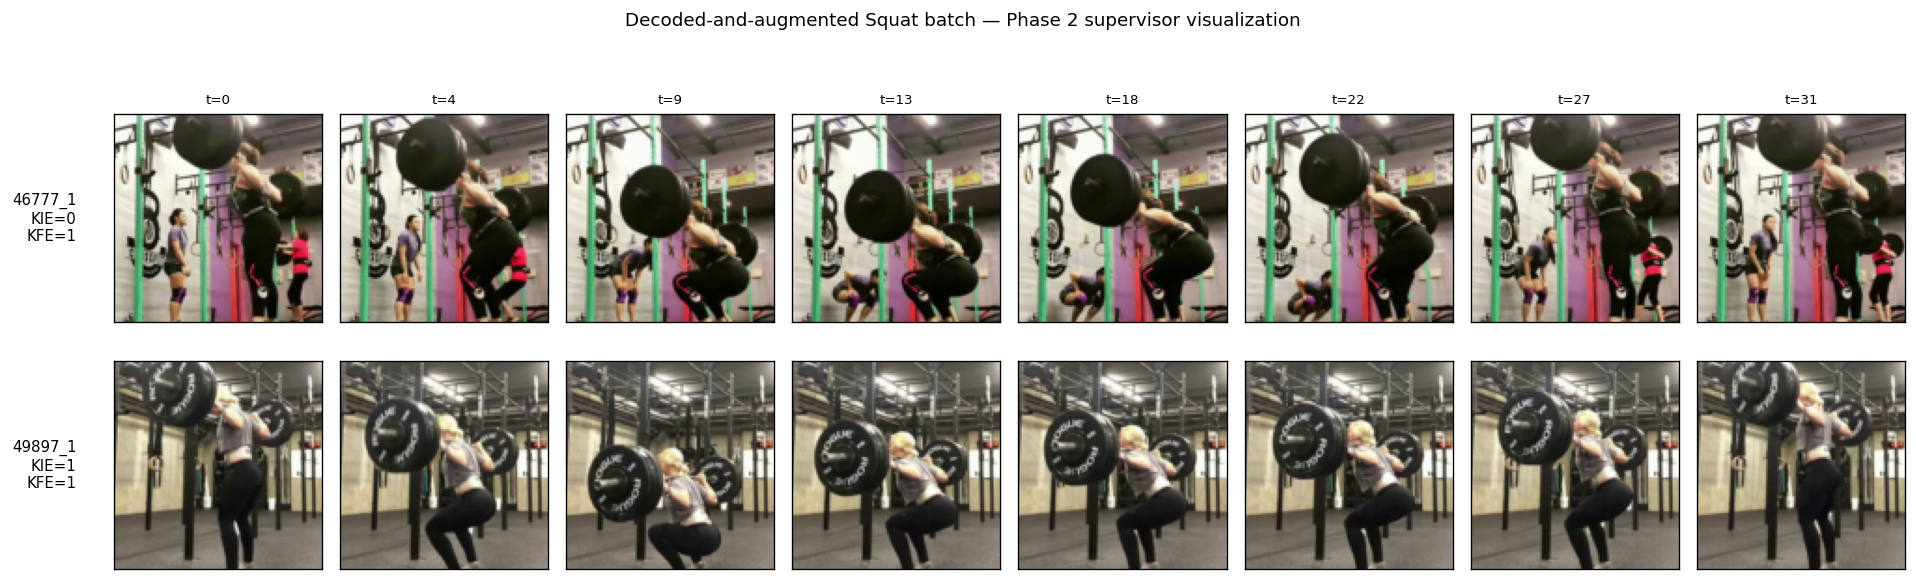

In [ ]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from backend.training.aqa.datasets.transforms import KINETICS_MEAN, KINETICS_STD
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset

train_ds = SquatKIEKFEDataset(
    split="train",
    drive_root="/content/drive/MyDrive",
    videos_root="/content/squat_videos",
    train_aug=True,
    seed=42,
)

items = [train_ds[i] for i in (0, 1)]
batch_clips = torch.stack([c for c, _ in items])
batch_labels = torch.stack([l for _, l in items])
clip_ids = [train_ds.records[i].clip_id for i in (0, 1)]

mean_t = torch.tensor(KINETICS_MEAN, dtype=torch.float32).view(3, 1, 1, 1)
std_t = torch.tensor(KINETICS_STD, dtype=torch.float32).view(3, 1, 1, 1)
display = (batch_clips * std_t.unsqueeze(0) + mean_t.unsqueeze(0)).clamp(0, 1)

frame_idx = np.linspace(0, 31, 8).round().astype(int)

fig, axes = plt.subplots(2, 8, figsize=(16, 5), dpi=120)
for row in range(2):
    label_kie = int(batch_labels[row, 0].item())
    label_kfe = int(batch_labels[row, 1].item())
    for col, fi in enumerate(frame_idx):
        ax = axes[row, col]
        frame = display[row, :, fi].permute(1, 2, 0).numpy()
        ax.imshow(frame)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"t={fi}", fontsize=8)
    axes[row, 0].text(
        -0.18, 0.5,
        f"{clip_ids[row]}\nKIE={label_kie}\nKFE={label_kfe}",
        fontsize=9, ha="right", va="center",
        transform=axes[row, 0].transAxes,
    )
fig.suptitle("Decoded-and-augmented Squat batch", fontsize=11, y=1.02)
plt.tight_layout()

FIG_PATH = Path("docs/figures/decoded_batch.png")
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_PATH, dpi=120, bbox_inches="tight")
print(f"saved : {FIG_PATH}")
print(f"size  : {FIG_PATH.stat().st_size / 1024:.1f} KB")
print(f"shape : batch={tuple(batch_clips.shape)} labels={tuple(batch_labels.shape)}")
print(f"clips : {clip_ids}")
print(f"labels: row0={batch_labels[0].tolist()} row1={batch_labels[1].tolist()}")
plt.show()

In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 16 (delta 13), reused 13 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 5.22 KiB | 890.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   69c3870..65e77e6  fresh-start -> origin/fresh-start
Updating 69c3870..65e77e6
Fast-forward
 backend/training/aqa/harness/colab.py              | 50 ++++++++++++++-
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 71 +++++++++++++++++++++-
 2 files changed, 116 insertions(+), 5 deletions(-)
65e77e6 (HEAD -> fresh-start, origin/fresh-start) feat(02): implement colab.py slice 2 — RNG capture/restore + cudnn determinism (Task 9)
37fd643 fix(02): replace Step 0 video probe with backend-only sanity check (Task 8)
69c3870 chore(02): auto-install PyAV in notebook Step 0 (Task 8 prereq)


In [ ]:
import os, random
import numpy as np
import torch
from backend.training.aqa.harness.colab import capture_rng_state, restore_rng_state

# (b) env-ordering audit — CUBLAS_WORKSPACE_CONFIG must already be set.
cubcfg = os.environ.get("CUBLAS_WORKSPACE_CONFIG")
assert cubcfg == ":4096:8", f"CUBLAS_WORKSPACE_CONFIG={cubcfg!r}, expected ':4096:8'"
print(f"env-ordering audit          : CUBLAS_WORKSPACE_CONFIG = {cubcfg}")

# (c) capture returns dict with exactly the 4 expected keys
s1 = capture_rng_state()
expected_keys = {"python", "numpy", "torch_cpu", "torch_cuda_all"}
assert set(s1.keys()) == expected_keys, f"keys={sorted(s1.keys())}, expected {sorted(expected_keys)}"
print(f"capture_rng_state keys      : {sorted(s1.keys())}")
print(f"  python state type         : {type(s1['python']).__name__}")
print(f"  numpy state type          : {type(s1['numpy']).__name__}")
print(f"  torch_cpu state           : Tensor[{tuple(s1['torch_cpu'].shape)}] dtype={s1['torch_cpu'].dtype}")
print(f"  torch_cuda_all            : {len(s1['torch_cuda_all'])} device state(s)")

# (d) drift the RNG state
_ = random.random()
_ = np.random.rand(8)
_ = torch.randn(8)
if torch.cuda.is_available():
    _ = torch.randn(8, device="cuda")

# (e + f) restore twice, consume the same sequence each time, compare.
def _consume() -> dict:
    return {
        "py": random.random(),
        "np": np.random.rand(5).tolist(),
        "cpu": torch.randn(5).tolist(),
        "cuda": torch.randn(5, device="cuda").tolist() if torch.cuda.is_available() else None,
    }

restore_rng_state(s1)
seq_a = _consume()
restore_rng_state(s1)
seq_b = _consume()

print("\n=== bitwise identity check (consume-twice after restore-twice) ===")
for k in seq_a:
    same = seq_a[k] == seq_b[k]
    print(f"  {k:5s}: {'OK' if same else 'DRIFT'}")
    assert same, f"{k} drifted: {seq_a[k]} vs {seq_b[k]}"
print("\nRNG capture/restore bitwise-identical: PASSED")

F8 audit                    : CUBLAS_WORKSPACE_CONFIG = :4096:8
capture_rng_state keys      : ['numpy', 'python', 'torch_cpu', 'torch_cuda_all']
  python state type         : tuple
  numpy state type          : tuple
  torch_cpu state           : Tensor[(5056,)] dtype=torch.uint8
  torch_cuda_all            : 1 device state(s)

=== bitwise identity check (consume-twice after restore-twice) ===
  py   : OK
  np   : OK
  cpu  : OK
  cuda : OK

RNG capture/restore bitwise-identical: PASSED


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9 (delta 7), reused 9 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 6.38 KiB | 284.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   65e77e6..5f03e43  fresh-start -> origin/fresh-start
Updating 65e77e6..5f03e43
Fast-forward
 backend/training/aqa/harness/colab.py              | 188 ++++++++++++++++++++-
 .../aqa/notebooks/02_squat_pipeline_harness.py     |  87 +++++++++-
 2 files changed, 266 insertions(+), 9 deletions(-)
5f03e43 (HEAD -> fresh-start, origin/fresh-start) feat(02): implement colab.py slice 3 — atomic checkpoint primitives (Task 10)
65e77e6 feat(02): implement colab.py slice 2 — RNG capture/restore + cudnn determinism (Task 9)
37fd643 fix(02): replace Step 0 video probe with backend-only sanity check (Task 8)


In [ ]:
import os, shutil, time
from pathlib import Path
import torch
from backend.training.aqa.harness.colab import (
    hash_config, atomic_save_checkpoint, load_latest_checkpoint,
    prune_checkpoints, CheckpointConfigMismatchError,
)

RUN_DIR = "/tmp/test_run"
if os.path.isdir(RUN_DIR):
    shutil.rmtree(RUN_DIR)
os.makedirs(RUN_DIR, exist_ok=True)

# (a) hash_config — key-order invariance
cfg1 = {"seed": 42, "crop_size": 112, "lr": 1e-4}
cfg2 = {"lr": 1e-4, "crop_size": 112, "seed": 42}
h1, h2 = hash_config(cfg1), hash_config(cfg2)
assert h1 == h2, f"hash mismatch on key order: {h1} vs {h2}"
print(f"(a) hash_config key-order invariant : {h1}  (16-char sha256)")

# (b) Round-trip
payload_e0 = {
    "epoch": 0,
    "model_state_dict": {"dummy.weight": torch.zeros(3)},
    "optimizer_state_dict": {}, "scheduler_state_dict": None,
    "rng_state": {}, "metrics_history": [{"epoch": 0, "train_loss_mean": 0.5}],
    "config_hash": h1, "config_repr": cfg1, "code_version": "test",
}
atomic_save_checkpoint(payload_e0, os.path.join(RUN_DIR, "epoch_000.pt"))
loaded = load_latest_checkpoint(RUN_DIR, expected_config_hash=h1)
assert loaded is not None and loaded["epoch"] == 0 and loaded["config_hash"] == h1
print(f"(b) round-trip                      : epoch={loaded['epoch']}, latest.txt -> "
      f"{Path(RUN_DIR, 'latest.txt').read_text().strip()}")

# (c) Config drift -> CheckpointConfigMismatchError
drifted_h = hash_config({**cfg1, "seed": 43})
try:
    _ = load_latest_checkpoint(RUN_DIR, expected_config_hash=drifted_h)
    raise AssertionError("expected CheckpointConfigMismatchError")
except CheckpointConfigMismatchError as exc:
    msg = str(exc)
    assert h1 in msg and drifted_h in msg
    print(f"(c) config drift -> error raised    : OK  (message contains both hashes + config_repr)")

# (d) Prune — write 3 more + best.pt, then prune
for ep in (1, 2, 3):
    payload = {**payload_e0, "epoch": ep}
    atomic_save_checkpoint(payload, os.path.join(RUN_DIR, f"epoch_{ep:03d}.pt"))
    time.sleep(0.01)
torch.save(payload_e0, os.path.join(RUN_DIR, "best.pt"))

before = sorted(f for f in os.listdir(RUN_DIR) if f.endswith(".pt"))
print(f"(d) before prune                    : {before}")
prune_checkpoints(RUN_DIR, keep_last=3, keep_best=True)
after = sorted(f for f in os.listdir(RUN_DIR) if f.endswith(".pt"))
print(f"(d) after  prune (keep_last=3+best) : {after}")

epoch_pts = [f for f in after if f.startswith("epoch_") and f.endswith(".pt")]
assert len(epoch_pts) == 3, f"expected 3, got {len(epoch_pts)}: {epoch_pts}"
assert "best.pt" in after, "best.pt was pruned despite keep_best=True"
assert "epoch_000.pt" not in after, "oldest should have been pruned"
print(f"\natomic checkpoint primitives: ALL PASSED")

(a) hash_config key-order invariant : 8ea34189e7baf8d4  (16-char sha256)
(b) round-trip                      : epoch=0, latest.txt -> epoch_000.pt
(c) config drift -> error raised    : OK  (message contains both hashes + config_repr)
(d) before prune                    : ['best.pt', 'epoch_000.pt', 'epoch_001.pt', 'epoch_002.pt', 'epoch_003.pt']
(d) after  prune (keep_last=3+best) : ['best.pt', 'epoch_001.pt', 'epoch_002.pt', 'epoch_003.pt']

Task 10 atomic checkpoint primitives: ALL PASSED


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 6.24 KiB | 399.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   5f03e43..872d2b8  fresh-start -> origin/fresh-start
Updating 5f03e43..872d2b8
Fast-forward
 backend/training/aqa/datasets/squat.py     |  40 ++---
 backend/training/aqa/harness/tiny_train.py | 246 ++++++++++++++++++++++++++++-
 2 files changed, 263 insertions(+), 23 deletions(-)
872d2b8 (HEAD -> fresh-start, origin/fresh-start) feat(02): implement harness/tiny_train.py + dataset RNG fix (Task 11)
5f03e43 feat(02): implement colab.py slice 3 — atomic checkpoint primitives (Task 10)
65e77e6 feat(02): implement colab.py slice 2 — RNG capture/restore + cudnn determinism (Task 9)


In [ ]:
# Cell GG — TinyModel shape + run_tiny_epoch(resume=False, max_epochs=1)
import torch
from backend.training.aqa.harness.tiny_train import TinyModel, run_tiny_epoch

# Shape contract
m = TinyModel()
x = torch.randn(2, 3, 32, 112, 112)
y = m(x)
print(f"TinyModel: input={tuple(x.shape)} -> output={tuple(y.shape)}")
assert tuple(y.shape) == (2, 2), y.shape

# Fresh 1-epoch run on the toy subset (16 train clips x batch_size=2 = 8 batches)
print("\n=== fresh tiny run (16 train / 4 val / 1 epoch / seed=42) ===")
result = run_tiny_epoch(
    run_name="squat_tiny_2026-05-20_t11verify",
    resume=False,
    max_epochs=1,
)

print(f"\nreturn keys: {sorted(result.keys())}")
expected_keys = {"epoch", "train_loss_per_batch", "val_loss_mean", "checkpoint_path", "config_hash"}
assert set(result.keys()) == expected_keys, (set(result.keys()), expected_keys)
print(f"  epoch                : {result['epoch']}")
print(f"  train_loss_per_batch : {result['train_loss_per_batch']}  ({len(result['train_loss_per_batch'])} batches)")
print(f"  val_loss_mean        : {result['val_loss_mean']:.6f}")
print(f"  checkpoint_path      : {result['checkpoint_path']}")
print(f"  config_hash          : {result['config_hash']}")

# Verify checkpoint is on Drive
import os
assert os.path.isfile(result['checkpoint_path']), result['checkpoint_path']
print(f"\nCheckpoint on Drive: OK ({os.path.getsize(result['checkpoint_path']) / 1024:.1f} KB)")

TinyModel: input=(2, 3, 32, 112, 112) -> output=(2, 2)

=== fresh tiny run (16 train / 4 val / 1 epoch / seed=42) ===


/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from v


return keys: ['checkpoint_path', 'config_hash', 'epoch', 'train_loss_per_batch', 'val_loss_mean']
  epoch                : 0
  train_loss_per_batch : [0.6668874025344849, 0.634411633014679, 0.6892452239990234, 0.7051372528076172, 0.6275745630264282, 0.6950815916061401, 0.681817889213562, 0.6740752458572388]  (8 batches)
  val_loss_mean        : 0.671285
  checkpoint_path      : /content/drive/MyDrive/FitNova/checkpoints/phase02/squat_tiny_2026-05-20_t11verify/epoch_000.pt
  config_hash          : 51d5de1e7a696843

Checkpoint on Drive: OK (23.5 KB)


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9 (delta 7), reused 9 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 3.20 KiB | 121.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   872d2b8..6f022df  fresh-start -> origin/fresh-start
Updating 872d2b8..6f022df
Fast-forward
 backend/training/aqa/harness/colab.py              | 12 ++++
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 78 ++++++++++++++++++++--
 2 files changed, 83 insertions(+), 7 deletions(-)
6f022df (HEAD -> fresh-start, origin/fresh-start) feat(02): Step 8a baseline 2-epoch + suppress torchvision deprecation noise (Task 12)
872d2b8 feat(02): implement harness/tiny_train.py + dataset RNG fix (Task 11)
5f03e43 feat(02): implement colab.py slice 3 — atomic checkpoint primitives (Task 10)


In [ ]:
# destructive, idempotent. Wipes the acceptance run dir
# so the baseline starts cold.
import shutil
RUN_NAME = "squat_tiny_2026-05-20_a1b2c3d"
RUN_DIR = f"/content/drive/MyDrive/FitNova/checkpoints/phase02/{RUN_NAME}/"
shutil.rmtree(RUN_DIR, ignore_errors=True)
print(f"cleaned : {RUN_DIR}")

cleaned : /content/drive/MyDrive/FitNova/checkpoints/phase02/squat_tiny_2026-05-20_a1b2c3d/


In [ ]:
from backend.training.aqa.harness.tiny_train import run_tiny_epoch

result_baseline = run_tiny_epoch(
    run_name=RUN_NAME,
    seed=42,
    resume=False,
    max_epochs=2,
)
print("\nresult_baseline:")
for k, v in result_baseline.items():
    if k == "train_loss_per_batch":
        print(f"  {k:22s}: {v}  ({len(v)} batches in LAST epoch)")
    else:
        print(f"  {k:22s}: {v}")


result_baseline:
  epoch                 : 1
  train_loss_per_batch  : [0.6895276308059692, 0.7017314434051514, 0.6577834486961365, 0.645598292350769, 0.661583662033081, 0.6390872597694397, 0.6730218529701233, 0.6817693710327148]  (8 batches in LAST epoch)
  val_loss_mean         : 0.6683911681175232
  checkpoint_path       : /content/drive/MyDrive/FitNova/checkpoints/phase02/squat_tiny_2026-05-20_a1b2c3d/epoch_001.pt
  config_hash           : 51d5de1e7a696843


In [ ]:
import json
from pathlib import Path
import torch, os

ckpt_path = RUN_DIR + "epoch_001.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

losses = {
    f"epoch_{m['epoch']}": m["train_loss_per_batch"]
    for m in ckpt["metrics_history"]
}
assert set(losses.keys()) == {"epoch_0", "epoch_1"}, losses.keys()
assert len(losses["epoch_0"]) == 8 and len(losses["epoch_1"]) == 8

out_path = Path("docs/figures/tiny_baseline_2epoch_losses.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as fh:
    json.dump(losses, fh)
print(f"saved : {out_path}")
print(f"  epoch_0: {losses['epoch_0']}")
print(f"  epoch_1: {losses['epoch_1']}")

print(f"\nrun_dir state:")
for f in sorted(os.listdir(RUN_DIR)):
    full = RUN_DIR + f
    if os.path.isfile(full):
        print(f"  {f:18s}  {os.path.getsize(full)} bytes")
print(f"latest.txt content : {Path(RUN_DIR, 'latest.txt').read_text().strip()!r}")

saved : /content/fitnova/.planning/phases/02-squat-data-pipeline-colab-harness/figures/tiny_baseline_2epoch_losses.json
  epoch_0: [0.6668874025344849, 0.634411633014679, 0.6892452239990234, 0.7051372528076172, 0.6275745630264282, 0.6950815916061401, 0.681817889213562, 0.6740752458572388]
  epoch_1: [0.6895276308059692, 0.7017314434051514, 0.6577834486961365, 0.645598292350769, 0.661583662033081, 0.6390872597694397, 0.6730218529701233, 0.6817693710327148]

run_dir state:
  epoch_000.pt        24093 bytes
  epoch_001.pt        24157 bytes
  latest.txt          13 bytes
latest.txt content : 'epoch_001.pt'


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 2.88 KiB | 421.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   6f022df..41a9b7b  fresh-start -> origin/fresh-start
Updating 6f022df..41a9b7b
Fast-forward
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 89 ++++++++++++++++++++++
 1 file changed, 89 insertions(+)
41a9b7b (HEAD -> fresh-start, origin/fresh-start) feat(02): Step 8b resume-after-simulated-restart (Task 13)
6f022df feat(02): Step 8a baseline 2-epoch + suppress torchvision deprecation noise (Task 12)
872d2b8 feat(02): implement harness/tiny_train.py + dataset RNG fix (Task 11)


In [ ]:
import os
from pathlib import Path

epoch_001 = RUN_DIR + "epoch_001.pt"
if os.path.exists(epoch_001):
    os.remove(epoch_001)
    print(f"removed   : {epoch_001}")
else:
    print(f"already gone: {epoch_001}")

with open(RUN_DIR + "latest.txt", "w", encoding="utf-8") as fh:
    fh.write("epoch_000.pt\n")
print(f"latest.txt rewound to: {Path(RUN_DIR, 'latest.txt').read_text().strip()!r}")

print(f"\nfiles on Drive now:")
for f in sorted(os.listdir(RUN_DIR)):
    full = RUN_DIR + f
    if os.path.isfile(full):
        print(f"  {f:18s}  {os.path.getsize(full)} bytes")

removed   : /content/drive/MyDrive/FitNova/checkpoints/phase02/squat_tiny_2026-05-20_a1b2c3d/epoch_001.pt
latest.txt rewound to: 'epoch_000.pt'

files on Drive now:
  epoch_000.pt        24093 bytes
  latest.txt          13 bytes


In [ ]:
import sys

mods = [k for k in sys.modules if k.startswith("backend.training.aqa")]
for k in mods:
    sys.modules.pop(k)
print(f"purged {len(mods)} modules: {sorted(mods)}")

from backend.training.aqa.harness.tiny_train import run_tiny_epoch
print(f"run_tiny_epoch re-loaded from: {run_tiny_epoch.__code__.co_filename}")

purged 9 modules: ['backend.training.aqa', 'backend.training.aqa.datasets', 'backend.training.aqa.datasets.splits', 'backend.training.aqa.datasets.squat', 'backend.training.aqa.datasets.transforms', 'backend.training.aqa.harness', 'backend.training.aqa.harness._envinit', 'backend.training.aqa.harness.colab', 'backend.training.aqa.harness.tiny_train']
run_tiny_epoch re-loaded from: /content/fitnova/backend/training/aqa/harness/tiny_train.py


In [ ]:
result_resumed = run_tiny_epoch(
    run_name=RUN_NAME,
    seed=42,
    resume=True,
    max_epochs=2,
)
print("\nresult_resumed:")
for k, v in result_resumed.items():
    if k == "train_loss_per_batch":
        print(f"  {k:22s}: {v}  ({len(v)} batches in LAST epoch)")
    else:
        print(f"  {k:22s}: {v}")

import json
from pathlib import Path
resumed_path = Path("docs/figures/tiny_resumed_epoch1_losses.json")
resumed_path.parent.mkdir(parents=True, exist_ok=True)
with open(resumed_path, "w") as fh:
    json.dump(result_resumed["train_loss_per_batch"], fh)
print(f"\nsaved : {resumed_path}")

import os
print(f"\nrun_dir state after resume:")
for f in sorted(os.listdir(RUN_DIR)):
    full = RUN_DIR + f
    if os.path.isfile(full):
        print(f"  {f:18s}  {os.path.getsize(full)} bytes")
print(f"latest.txt content : {Path(RUN_DIR, 'latest.txt').read_text().strip()!r}")


result_resumed:
  epoch                 : 1
  train_loss_per_batch  : [0.6895276308059692, 0.7017314434051514, 0.6577834486961365, 0.645598292350769, 0.661583662033081, 0.6390872597694397, 0.6730218529701233, 0.6817693710327148]  (8 batches in LAST epoch)
  val_loss_mean         : 0.6683911681175232
  checkpoint_path       : /content/drive/MyDrive/FitNova/checkpoints/phase02/squat_tiny_2026-05-20_a1b2c3d/epoch_001.pt
  config_hash           : 51d5de1e7a696843

saved : /content/fitnova/.planning/phases/02-squat-data-pipeline-colab-harness/figures/tiny_resumed_epoch1_losses.json

run_dir state after resume:
  epoch_000.pt        24093 bytes
  epoch_001.pt        24221 bytes
  latest.txt          13 bytes
latest.txt content : 'epoch_001.pt'


In [ ]:
!cd /content/fitnova && git pull --ff-only origin fresh-start && git log --oneline -3

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 3.84 KiB | 302.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
   41a9b7b..b16bd18  fresh-start -> origin/fresh-start
Updating 41a9b7b..b16bd18
Fast-forward
 .../aqa/notebooks/02_squat_pipeline_harness.py     | 117 +++++++++++++++++++++
 1 file changed, 117 insertions(+)
b16bd18 (HEAD -> fresh-start, origin/fresh-start) feat(02): Step 8c bitwise-equivalence assertion + overlay plot (Task 14)
41a9b7b feat(02): Step 8b resume-after-simulated-restart (Task 13)
6f022df feat(02): Step 8a baseline 2-epoch + suppress torchvision deprecation noise (Task 12)


baseline epoch_1 (8 batches):
  batch 0: 0.6895276308059692
  batch 1: 0.7017314434051514
  batch 2: 0.6577834486961365
  batch 3: 0.645598292350769
  batch 4: 0.661583662033081
  batch 5: 0.6390872597694397
  batch 6: 0.6730218529701233
  batch 7: 0.6817693710327148

resumed  epoch_1 (8 batches):
  batch 0: 0.6895276308059692
  batch 1: 0.7017314434051514
  batch 2: 0.6577834486961365
  batch 3: 0.645598292350769
  batch 4: 0.661583662033081
  batch 5: 0.6390872597694397
  batch 6: 0.6730218529701233
  batch 7: 0.6817693710327148

BITWISE EQUAL: epoch-1 losses match across 8 batches

saved : /content/fitnova/.planning/phases/02-squat-data-pipeline-colab-harness/figures/tiny_train_loss.png
size  : 79.7 KB


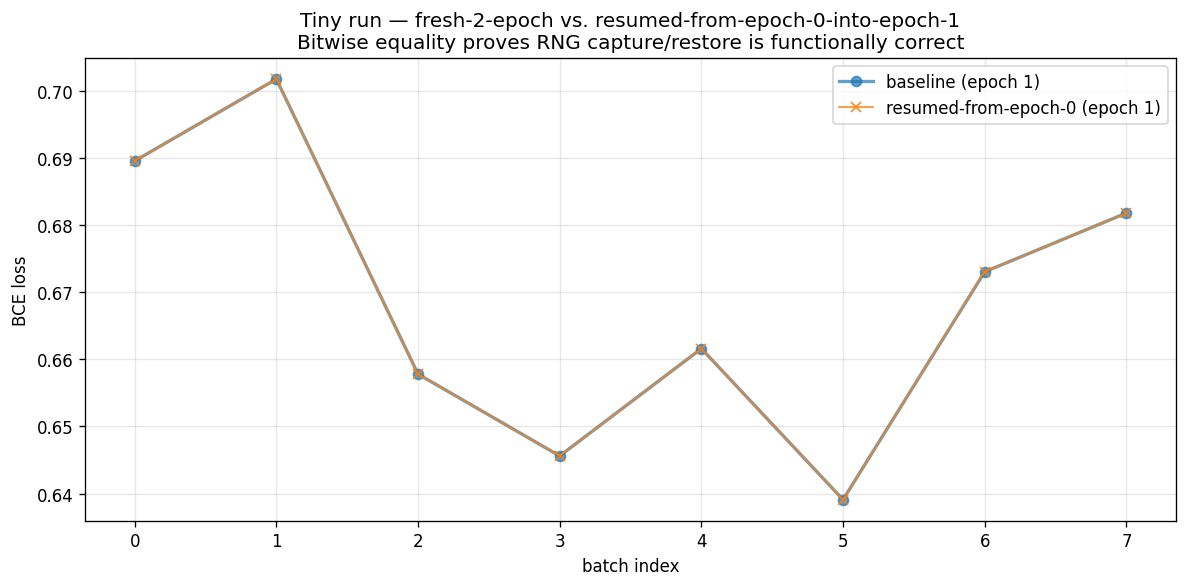

In [ ]:
# Acceptance proof: fresh-2-epoch vs. resumed-from-epoch-0-into-epoch-1 —
# bitwise equality proves RNG capture/restore is functionally correct.
import json
from pathlib import Path
import matplotlib.pyplot as plt

baseline_path = Path("docs/figures/tiny_baseline_2epoch_losses.json")
resumed_path = Path("docs/figures/tiny_resumed_epoch1_losses.json")

with open(baseline_path) as fh:
    baseline = json.load(fh)
with open(resumed_path) as fh:
    resumed_epoch1 = json.load(fh)

baseline_epoch1 = baseline["epoch_1"]

print(f"baseline epoch_1 ({len(baseline_epoch1)} batches):")
for i, v in enumerate(baseline_epoch1):
    print(f"  batch {i}: {v!r}")
print(f"\nresumed  epoch_1 ({len(resumed_epoch1)} batches):")
for i, v in enumerate(resumed_epoch1):
    print(f"  batch {i}: {v!r}")

if baseline_epoch1 == resumed_epoch1:
    print(f"\n{'=' * 60}")
    print(f"BITWISE EQUAL: epoch-1 losses match across {len(baseline_epoch1)} batches")
    print(f"{'=' * 60}")
else:
    diff_idx = None
    for i, (b, r) in enumerate(zip(baseline_epoch1, resumed_epoch1)):
        if b != r:
            diff_idx = i; break
    raise AssertionError(
        f"BITWISE INEQUALITY at batch index {diff_idx}: "
        f"baseline={baseline_epoch1[diff_idx]!r} resumed={resumed_epoch1[diff_idx]!r}. "
        f"Check the determinism setup (seeding, RNG capture/restore, deterministic ops)."
    )

out_png = Path("docs/figures/tiny_train_loss.png")
out_png.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(baseline_epoch1, marker="o", linewidth=2, alpha=0.7, label="baseline (epoch 1)")
ax.plot(resumed_epoch1, marker="x", linewidth=1, alpha=0.9, label="resumed-from-epoch-0 (epoch 1)")
ax.set_xlabel("batch index")
ax.set_ylabel("BCE loss")
ax.set_title(
    "Tiny run — fresh-2-epoch vs. resumed-from-epoch-0-into-epoch-1\n"
    "Bitwise equality proves RNG capture/restore is functionally correct"
)
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(out_png)
print(f"\nsaved : {out_png}")
print(f"size  : {out_png.stat().st_size / 1024:.1f} KB")
plt.show()

In [ ]:
# Cell RR — Bundle the 4 figure files into a single ZIP for download.
# Save to your local FitNova repo at docs/figures/ (overwriting any older versions).
import shutil
from pathlib import Path

fig_src = Path("docs/figures")
out_dir = Path("/content")
zip_base = out_dir / "phase02_figures"

# Create a clean staging dir so the zip has a tidy root.
stage = out_dir / "_phase02_figures_stage"
if stage.exists():
    shutil.rmtree(stage)
stage.mkdir()

for name in ("decoded_batch.png", "tiny_train_loss.png",
             "tiny_baseline_2epoch_losses.json", "tiny_resumed_epoch1_losses.json"):
    src = fig_src / name
    if src.is_file():
        shutil.copy(src, stage / name)
        print(f"  staged: {name}  ({src.stat().st_size} bytes)")
    else:
        print(f"  MISSING: {name}")

zip_path = shutil.make_archive(str(zip_base), "zip", str(stage))
print(f"\nzip ready: {zip_path}  ({Path(zip_path).stat().st_size} bytes)")

from google.colab import files
files.download(zip_path)

  staged: decoded_batch.png  (1037375 bytes)
  staged: tiny_train_loss.png  (81572 bytes)
  staged: tiny_baseline_2epoch_losses.json  (342 bytes)
  staged: tiny_resumed_epoch1_losses.json  (158 bytes)

zip ready: /content/phase02_figures.zip  (1109698 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>